#### Import Libraries 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots (using the updated method)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

#### Load the data

In [9]:
# Load the dataset
# This correctly points to the file in the 'data' folder, one level up
df = pd.read_csv("../data/TSLA.csv")

# Display first few rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


#### Basic inspection

In [10]:
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()
print("\nSummary statistics:")
df.describe()

Dataset shape: (2416, 7)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB

Summary statistics:


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


#### Check for missing values

In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


#### Convert Date to datetime and set as index

In [12]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as index
df.set_index('Date', inplace=True)

# Show updated DataFrame
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


#### Plot Adjusted Close price trend

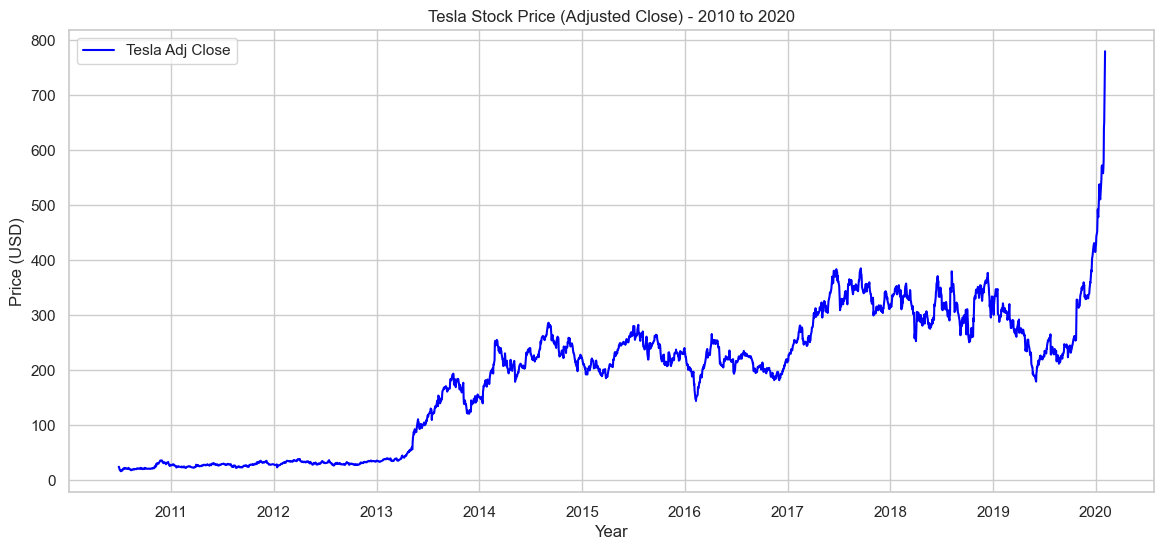

In [13]:
# Plot Adj Close over time
plt.plot(df.index, df['Adj Close'], label='Tesla Adj Close', color='blue')
plt.title('Tesla Stock Price (Adjusted Close) - 2010 to 2020')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Data Preprocessing

#### Extract Target Variable

In [15]:
# Select only the 'Adj Close' column as our target
data = df['Adj Close'].values.reshape(-1, 1)

print("Shape of target data:", data.shape)

Shape of target data: (2416, 1)


#### Normalize the Data

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform the data
data_scaled = scaler.fit_transform(data)

print("Data scaled between 0 and 1.")
print("Min:", data_scaled.min(), "Max:", data_scaled.max())

Data scaled between 0 and 1.
Min: 0.0 Max: 1.0


####  Create Time-Series Sequences (Sliding Window)

In [17]:
def create_sequences(data, window_size=60, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i+window_size])          # Past 'window_size' days
        y.append(data[i+window_size:i+window_size+forecast_horizon])  # Next 'forecast_horizon' days
    return np.array(X), np.array(y)

#### Define Parameters & Create Sequences for 1-Day Forecast

In [18]:
# Parameters
WINDOW_SIZE = 60  # Use last 60 days to predict next day
FORECAST_HORIZON = 1  # Predict 1 day ahead

# Create sequences
X_1d, y_1d = create_sequences(data_scaled, window_size=WINDOW_SIZE, forecast_horizon=FORECAST_HORIZON)

print("X_1d shape:", X_1d.shape)   # (2355, 60, 1)
print("y_1d shape:", y_1d.shape)   # (2355, 1)

X_1d shape: (2356, 60, 1)
y_1d shape: (2356, 1, 1)


#### Split into Train and Test Sets (Chronologically!)

In [19]:
# Calculate split index (80% train, 20% test)
split_index = int(len(X_1d) * 0.8)

# Split data
X_train_1d = X_1d[:split_index]
y_train_1d = y_1d[:split_index]
X_test_1d = X_1d[split_index:]
y_test_1d = y_1d[split_index:]

print("Train shape:", X_train_1d.shape, y_train_1d.shape)
print("Test shape:", X_test_1d.shape, y_test_1d.shape)

Train shape: (1884, 60, 1) (1884, 1, 1)
Test shape: (472, 60, 1) (472, 1, 1)


#### Repeat for 5-Day and 10-Day Forecasts

In [20]:
# For 5-day forecast
FORECAST_HORIZON_5 = 5
X_5d, y_5d = create_sequences(data_scaled, window_size=WINDOW_SIZE, forecast_horizon=FORECAST_HORIZON_5)

split_index_5 = int(len(X_5d) * 0.8)
X_train_5d = X_5d[:split_index_5]
y_train_5d = y_5d[:split_index_5]
X_test_5d = X_5d[split_index_5:]
y_test_5d = y_5d[split_index_5:]

print("5-day: Train", X_train_5d.shape, "Test", X_test_5d.shape)

# For 10-day forecast
FORECAST_HORIZON_10 = 10
X_10d, y_10d = create_sequences(data_scaled, window_size=WINDOW_SIZE, forecast_horizon=FORECAST_HORIZON_10)

split_index_10 = int(len(X_10d) * 0.8)
X_train_10d = X_10d[:split_index_10]
y_train_10d = y_10d[:split_index_10]
X_test_10d = X_10d[split_index_10:]
y_test_10d = y_10d[split_index_10:]

print("10-day: Train", X_train_10d.shape, "Test", X_test_10d.shape)

5-day: Train (1881, 60, 1) Test (471, 60, 1)
10-day: Train (1877, 60, 1) Test (470, 60, 1)


## Model Development (SimpleRNN & LSTM)